In [ ]:

import pandas as pd 
import numpy as np
df=pd.read_csv(r"C:\Users\Vaish\Desktop\ML LAB DATASETS LOGISTIC REGRESSION\BATCH-6\26_transaction_fraud.csv")




In [21]:
print("------------HEAD---------------")
print(df.head())
print("-----------TAIL-----------------")
print(df.tail())
print("--------------DESCRIBE-----------")
print(df.describe())
print("----------------INFO-------------")
print(df.info())
print("--------------------MISSING VALUES----------------")
print(df.isnull().sum())


------------HEAD---------------
   transaction_amount_usd  hour_of_day  num_transactions_today  \
0                 2732.90           19                       3   
1                 2885.92            2                      10   
2                 2645.93            6                      18   
3                 2208.94            0                       4   
4                 1242.77           23                      27   

   distance_from_home_km employment_type region marital_status  is_fraud  
0                 290.71   Self-employed  North        Married         1  
1                 239.69       Full-time  North        Married         0  
2                 437.94   Self-employed   East        Married         1  
3                 277.93       Full-time  South        Married         0  
4                 498.85      Unemployed   East        Married         1  
-----------TAIL-----------------
     transaction_amount_usd  hour_of_day  num_transactions_today  \
295                 

In [22]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 12)
Testing data: (60, 12)


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\megha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
z = model.decision_function(X_test)

probability = 1 / (1 + np.exp(-z))

print(probability[:10])

[0.60664434 0.1617181  0.41879097 0.89514402 0.49153442 0.55821195
 0.1355005  0.82144417 0.61667189 0.66925716]


In [25]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Predicted labels:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[1 0 0 1 0 1 0 1 1 1]

Predicted probabilities:
[0.60664434 0.1617181  0.41879097 0.89514402 0.49153442 0.55821195
 0.1355005  0.82144417 0.61667189 0.66925716]


In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[16  8]
 [11 25]]
Accuracy: 0.6833333333333333
Precision: 0.7575757575757576
Recall: 0.6944444444444444
F1 Score: 0.7246376811594203


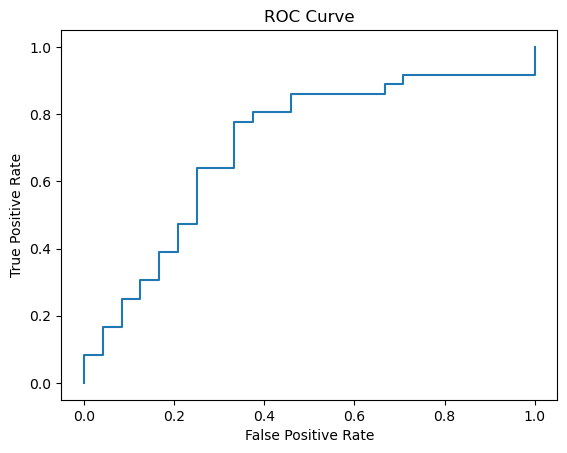

AUC: 0.7060185185185185


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc)

In [28]:
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

print(y_pred_new[:20])

[0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0]


In [29]:
new_data = pd.DataFrame({
    "transaction_amount_usd": [2500],
    "hour_of_day": [14],
    "num_transactions_today": [5],
    "distance_from_home_km": [10],
    "employment_type": ["Salaried"],
    "region": ["Urban"],
    "marital_status": ["Married"]
})

new_data = pd.get_dummies(new_data, drop_first=True)

new_data = new_data.reindex(columns=X.columns, fill_value=0)

new_probability = model.predict_proba(new_data)[:, 1]
new_prediction = (new_probability >= 0.7).astype(int)

print("Fraud probability:", new_probability[0])
print("Prediction:", new_prediction[0])

Fraud probability: 0.13735258748914203
Prediction: 0
